In [19]:
import akshare as ak
import pandas as pd

# 用一个简单接口测试，不依赖ipywidgets
df_test = ak.stock_zh_index_daily(symbol="sh000001")
print(df_test.shape)
print(df_test.tail())

(8628, 6)
            date      open      high       low     close       volume
8623  2026-04-20  4053.375  4083.190  4051.685  4082.127  58984137900
8624  2026-04-21  4075.845  4086.637  4062.133  4085.077  57668945000
8625  2026-04-22  4074.813  4106.844  4074.680  4106.258  58246634600
8626  2026-04-23  4110.788  4114.844  4070.460  4093.250  67116609200
8627  2026-04-24  4081.033  4092.613  4061.145  4079.900  60503179800


AkShare在PyCharm里跑通了，数据格式也很干净

正式拉申万行业数据

In [22]:
# 测试拉农林牧渔行业指数历史数据
df_test = ak.index_hist_sw(symbol="801010", period="day")
print(df_test.shape)
print(df_test.head())
print(df_test.columns.tolist())

(6358, 8)
       代码          日期       收盘       开盘       最高       最低       成交量       成交额
0  801010  1999-12-30  1000.00  1000.00  1000.00  1000.00  0.098647  1.239666
1  801010  2000-01-04  1027.66  1001.98  1035.36   985.47  0.140116  1.831998
2  801010  2000-01-05  1028.87  1035.47  1057.85  1013.07  0.253309  2.904446
3  801010  2000-01-06  1065.67  1025.38  1070.79  1011.00  0.302028  4.214445
4  801010  2000-01-07  1106.19  1076.06  1117.71  1058.83  0.648305  8.751578
['代码', '日期', '收盘', '开盘', '最高', '最低', '成交量', '成交额']


数据格式清晰，从1999年到现在6358条记录。我们只用2021-2024年的数据

批量拉取28个行业指数数据

In [26]:
import time

sw_level1 = {
    '801010': '农林牧渔',
    '801020': '采掘',
    '801030': '化工',
    '801040': '钢铁',
    '801050': '有色金属',
    '801080': '电子',
    '801110': '家用电器',
    '801120': '食品饮料',
    '801130': '纺织服装',
    '801140': '轻工制造',
    '801150': '医药生物',
    '801160': '公用事业',
    '801170': '交通运输',
    '801180': '房地产',
    '801200': '商业贸易',
    '801210': '休闲服务',
    '801230': '综合',
    '801710': '建筑材料',
    '801720': '建筑装饰',
    '801730': '电气设备',
    '801740': '国防军工',
    '801750': '计算机',
    '801760': '传媒',
    '801770': '通信',
    '801780': '银行',
    '801790': '非银金融',
    '801880': '汽车',
    '801890': '机械设备',
}

all_data = []

for code, name in sw_level1.items():
    df = ak.index_hist_sw(symbol=code, period="day")
    df = df[['代码', '日期', '收盘']]
    # 统一转成datetime格式再过滤
    df['日期'] = pd.to_datetime(df['日期'])
    df = df[(df['日期'] >= '2021-01-01') & (df['日期'] <= '2024-12-31')]
    df['行业名称'] = name
    all_data.append(df)
    print(f'完成：{name} ({code})，共 {len(df)} 条')
    time.sleep(0.3)

df_raw = pd.concat(all_data, ignore_index=True)
print(f'\n全部完成，总数据量：{df_raw.shape}')
print(df_raw.head(10))

完成：农林牧渔 (801010)，共 959 条
完成：采掘 (801020)，共 225 条
完成：化工 (801030)，共 959 条
完成：钢铁 (801040)，共 959 条
完成：有色金属 (801050)，共 959 条
完成：电子 (801080)，共 959 条
完成：家用电器 (801110)，共 959 条
完成：食品饮料 (801120)，共 959 条
完成：纺织服装 (801130)，共 959 条
完成：轻工制造 (801140)，共 959 条
完成：医药生物 (801150)，共 959 条
完成：公用事业 (801160)，共 959 条
完成：交通运输 (801170)，共 959 条
完成：房地产 (801180)，共 959 条
完成：商业贸易 (801200)，共 959 条
完成：休闲服务 (801210)，共 959 条
完成：综合 (801230)，共 959 条
完成：建筑材料 (801710)，共 959 条
完成：建筑装饰 (801720)，共 959 条
完成：电气设备 (801730)，共 959 条
完成：国防军工 (801740)，共 959 条
完成：计算机 (801750)，共 959 条
完成：传媒 (801760)，共 959 条
完成：通信 (801770)，共 959 条
完成：银行 (801780)，共 959 条
完成：非银金融 (801790)，共 959 条
完成：汽车 (801880)，共 959 条
完成：机械设备 (801890)，共 959 条

全部完成，总数据量：(26118, 4)
       代码         日期       收盘  行业名称
0  801010 2021-01-04  4181.35  农林牧渔
1  801010 2021-01-05  4335.03  农林牧渔
2  801010 2021-01-06  4345.40  农林牧渔
3  801010 2021-01-07  4374.91  农林牧渔
4  801010 2021-01-08  4285.38  农林牧渔
5  801010 2021-01-11  4091.76  农林牧渔
6  801010 2021-01-12  4135.45  农林牧渔
7  801010 

28个行业全部拉取成功，26118条数据，格式干净。注意采掘只有225条，后面要处理一下

In [28]:
 # 保存到data/raw目录，避免每次重新拉取
import os

os.makedirs('../data/raw', exist_ok=True)
df_raw.to_csv('../data/raw/sw_industry_daily.csv', index=False, encoding='utf-8-sig')
print('数据已保存至 data/raw/sw_industry_daily.csv')
print(f'数据时间范围：{df_raw["日期"].min()} 至 {df_raw["日期"].max()}')
print(f'行业数量：{df_raw["行业名称"].nunique()}')
print(f'\n各行业数据量：')
print(df_raw.groupby('行业名称')['日期'].count().sort_values())

数据已保存至 data/raw/sw_industry_daily.csv
数据时间范围：2021-01-04 00:00:00 至 2024-12-31 00:00:00
行业数量：28

各行业数据量：
行业名称
采掘      225
交通运输    959
传媒      959
休闲服务    959
农林牧渔    959
化工      959
医药生物    959
公用事业    959
国防军工    959
家用电器    959
建筑材料    959
建筑装饰    959
房地产     959
有色金属    959
机械设备    959
商业贸易    959
汽车      959
电子      959
纺织服装    959
电气设备    959
综合      959
计算机     959
轻工制造    959
通信      959
钢铁      959
银行      959
非银金融    959
食品饮料    959
Name: 日期, dtype: int64


采掘只有225条，大概率是申万2021年调整了行业分类，把"采掘"改名为"煤炭"和"石油石化"了。这个行业数据不完整，后面分析时排除掉就行

数据清洗，计算日涨跌幅

In [29]:
# 排除采掘（数据不完整）
df_clean = df_raw[df_raw['行业名称'] != '采掘'].copy()

# 按行业分组计算日涨跌幅
df_clean = df_clean.sort_values(['行业名称', '日期']).reset_index(drop=True)
df_clean['日涨跌幅'] = df_clean.groupby('行业名称')['收盘'].pct_change()

# 删除每个行业第一行（涨跌幅为NaN）
df_clean = df_clean.dropna(subset=['日涨跌幅']).reset_index(drop=True)

# 检查结果
print(f'清洗后数据量：{df_clean.shape}')
print(f'涨跌幅范围：{df_clean["日涨跌幅"].min():.4f} 至 {df_clean["日涨跌幅"].max():.4f}')
print(df_clean.head(10))

清洗后数据量：(25866, 5)
涨跌幅范围：-0.1100 至 0.1324
       代码         日期       收盘  行业名称      日涨跌幅
0  801170 2021-01-05  2439.05  交通运输  0.009624
1  801170 2021-01-06  2410.20  交通运输 -0.011828
2  801170 2021-01-07  2380.66  交通运输 -0.012256
3  801170 2021-01-08  2393.19  交通运输  0.005263
4  801170 2021-01-11  2348.03  交通运输 -0.018870
5  801170 2021-01-12  2363.56  交通运输  0.006614
6  801170 2021-01-13  2390.63  交通运输  0.011453
7  801170 2021-01-14  2362.98  交通运输 -0.011566
8  801170 2021-01-15  2361.84  交通运输 -0.000482
9  801170 2021-01-18  2382.62  交通运输  0.008798


原始26118条，去掉采掘225条剩25893条，再去掉每个行业第一行（27个行业各去掉1行）= 25893 - 27 = 25866条

拉取沪深300作为市场基准

In [30]:
# 拉取沪深300指数作为市场基准
df_hs300 = ak.stock_zh_index_daily(symbol="sh000300")
df_hs300 = df_hs300[['date', 'close']].copy()
df_hs300.columns = ['日期', '收盘']
df_hs300['日期'] = pd.to_datetime(df_hs300['日期'])
df_hs300 = df_hs300[(df_hs300['日期'] >= '2021-01-01') & (df_hs300['日期'] <= '2024-12-31')]
df_hs300 = df_hs300.sort_values('日期').reset_index(drop=True)

# 计算日涨跌幅
df_hs300['日涨跌幅'] = df_hs300['收盘'].pct_change()
df_hs300 = df_hs300.dropna().reset_index(drop=True)

print(f'沪深300数据量：{df_hs300.shape}')
print(df_hs300.head())
print(f'\n时间范围：{df_hs300["日期"].min()} 至 {df_hs300["日期"].max()}')

沪深300数据量：(968, 3)
          日期        收盘      日涨跌幅
0 2021-01-05  5368.505  0.019133
1 2021-01-06  5417.668  0.009158
2 2021-01-07  5513.657  0.017718
3 2021-01-08  5495.431 -0.003306
4 2021-01-11  5441.158 -0.009876

时间范围：2021-01-05 00:00:00 至 2024-12-31 00:00:00


沪深300数据正常，968条。注意到它比行业数据多9条（968 vs 959），是因为部分交易日行业指数没有数据，后面合并时会自动对齐，不影响分析

计算20日滚动收益率，划分市场环境

In [31]:
# 计算沪深300的20日滚动收益率
df_hs300['20日滚动收益'] = df_hs300['收盘'].pct_change(periods=20)

# 定义市场环境
def label_market(r):
    if r > 0.05:
        return '上涨期'
    elif r < -0.05:
        return '下跌期'
    else:
        return '震荡期'

df_hs300['市场环境'] = df_hs300['20日滚动收益'].apply(label_market)
df_hs300 = df_hs300.dropna(subset=['20日滚动收益']).reset_index(drop=True)

# 查看各环境分布
print(df_hs300['市场环境'].value_counts())
print(f'\n占比：')
print(df_hs300['市场环境'].value_counts(normalize=True).round(3))

# 预览
print(f'\n数据预览：')
print(df_hs300[['日期', '收盘', '20日滚动收益', '市场环境']].head(10))

市场环境
震荡期    714
下跌期    138
上涨期     96
Name: count, dtype: int64

占比：
市场环境
震荡期    0.753
下跌期    0.146
上涨期    0.101
Name: proportion, dtype: float64

数据预览：
          日期        收盘   20日滚动收益 市场环境
0 2021-02-02  5501.092  0.024697  震荡期
1 2021-02-03  5485.201  0.012465  震荡期
2 2021-02-04  5473.948 -0.007202  震荡期
3 2021-02-05  5483.414 -0.002187  震荡期
4 2021-02-08  5564.562  0.022680  震荡期
5 2021-02-09  5686.250  0.016063  震荡期
6 2021-02-10  5807.719  0.041188  震荡期
7 2021-02-18  5768.381  0.054461  上涨期
8 2021-02-19  5778.842  0.058768  上涨期
9 2021-02-22  5597.333  0.014281  震荡期


市场环境划分合理，震荡期占75%符合A股实际情况

把市场环境标签合并到行业数据里

In [32]:
# 只保留日期和市场环境两列用于合并
df_regime = df_hs300[['日期', '市场环境']].copy()

# 合并到行业数据
df_merged = pd.merge(df_clean, df_regime, on='日期', how='inner')

# 检查结果
print(f'合并后数据量：{df_merged.shape}')
print(f'覆盖交易日数：{df_merged["日期"].nunique()}')
print(f'行业数量：{df_merged["行业名称"].nunique()}')
print(f'\n各市场环境下的交易日数：')
print(df_merged.groupby('市场环境')['日期'].nunique())
print(f'\n数据预览：')
print(df_merged.head())

合并后数据量：(25326, 6)
覆盖交易日数：938
行业数量：27

各市场环境下的交易日数：
市场环境
上涨期     95
下跌期    134
震荡期    709
Name: 日期, dtype: int64

数据预览：
       代码         日期       收盘  行业名称      日涨跌幅 市场环境
0  801170 2021-02-02  2337.91  交通运输 -0.006392  震荡期
1  801170 2021-02-03  2302.93  交通运输 -0.014962  震荡期
2  801170 2021-02-04  2274.43  交通运输 -0.012376  震荡期
3  801170 2021-02-05  2278.66  交通运输  0.001860  震荡期
4  801170 2021-02-08  2292.42  交通运输  0.006039  震荡期


合并成功，938个交易日，27个行业，数据结构清晰

计算各行业在不同市场环境下的超额收益

In [33]:
# 把沪深300日涨跌幅也合并进来，用于计算超额收益
df_hs300_ret = df_hs300[['日期', '日涨跌幅']].rename(columns={'日涨跌幅': '沪深300涨跌幅'})
df_merged = pd.merge(df_merged, df_hs300_ret, on='日期', how='inner')

# 计算超额收益 = 行业日涨跌幅 - 沪深300日涨跌幅
df_merged['超额收益'] = df_merged['日涨跌幅'] - df_merged['沪深300涨跌幅']

# 按行业 × 市场环境分组，计算平均超额收益
df_alpha = df_merged.groupby(['行业名称', '市场环境']).agg(
    平均超额收益=('超额收益', 'mean'),
    胜率=('超额收益', lambda x: (x > 0).mean()),
    样本数=('超额收益', 'count')
).round(4).reset_index()

print(df_alpha.head(12))
print(f'\n共 {len(df_alpha)} 条分组记录')

    行业名称 市场环境  平均超额收益      胜率  样本数
0   交通运输  上涨期 -0.0011  0.4947   95
1   交通运输  下跌期  0.0008  0.4776  134
2   交通运输  震荡期  0.0004  0.5176  709
3   休闲服务  上涨期  0.0012  0.5368   95
4   休闲服务  下跌期 -0.0005  0.4552  134
5   休闲服务  震荡期 -0.0001  0.5162  709
6     传媒  上涨期  0.0023  0.5474   95
7     传媒  下跌期 -0.0004  0.5224  134
8     传媒  震荡期  0.0002  0.4838  709
9   公用事业  上涨期 -0.0017  0.4842   95
10  公用事业  下跌期  0.0021  0.5224  134
11  公用事业  震荡期  0.0006  0.5219  709

共 81 条分组记录


公用事业在下跌期超额收益0.0021，上涨期是-0.0017，典型防御性行业特征

做核心可视化：热力图

Exception ignored in: <function tqdm.__del__ at 0x00000203D5E15080>
Traceback (most recent call last):
  File "C:\Users\Lenovo\PycharmProjects\A股行业轮动规律分析\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\Lenovo\PycharmProjects\A股行业轮动规律分析\.venv\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


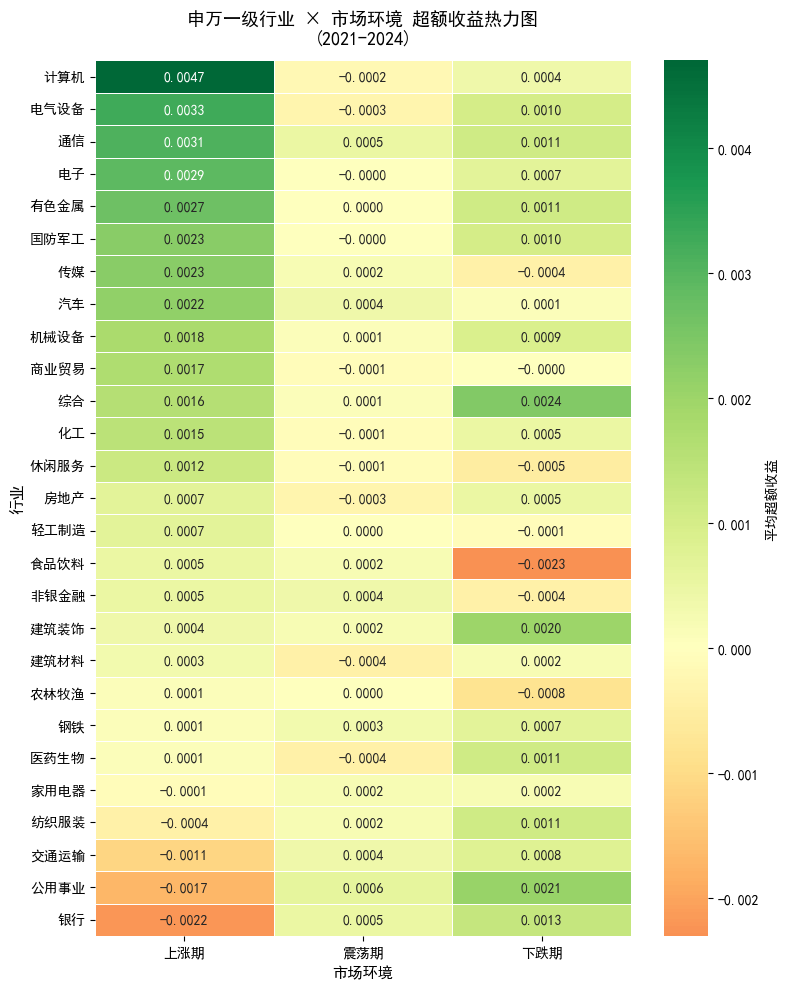

图已保存


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 解决中文显示问题
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 把数据转成宽表：行=行业，列=市场环境
pivot_alpha = df_alpha.pivot(
    index='行业名称',
    columns='市场环境',
    values='平均超额收益'
)[['上涨期', '震荡期', '下跌期']]  # 固定列顺序

# 按上涨期超额收益排序，方便看规律
pivot_alpha = pivot_alpha.sort_values('上涨期', ascending=False)

# 画热力图
fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    pivot_alpha,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '平均超额收益'}
)

ax.set_title('申万一级行业 × 市场环境 超额收益热力图\n(2021-2024)', fontsize=13, pad=12)
ax.set_xlabel('市场环境', fontsize=11)
ax.set_ylabel('行业', fontsize=11)

plt.tight_layout()
plt.savefig('../data/heatmap_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

上涨期领涨：计算机、电气设备、通信、电子、有色金属排前五，全是成长/周期类，符合牛市弹性大的逻辑。

下跌期抗跌：公用事业、银行、综合、建筑装饰超额收益为正，防御属性明显。

食品饮料有意思：下跌期超额收益-0.0023，是下跌期表现最差的行业之一，说明2021-2024这段时间消费股并不防御，背后是白酒估值杀跌的逻辑

第11格——再做一张胜率热力图，和超额收益对照着看

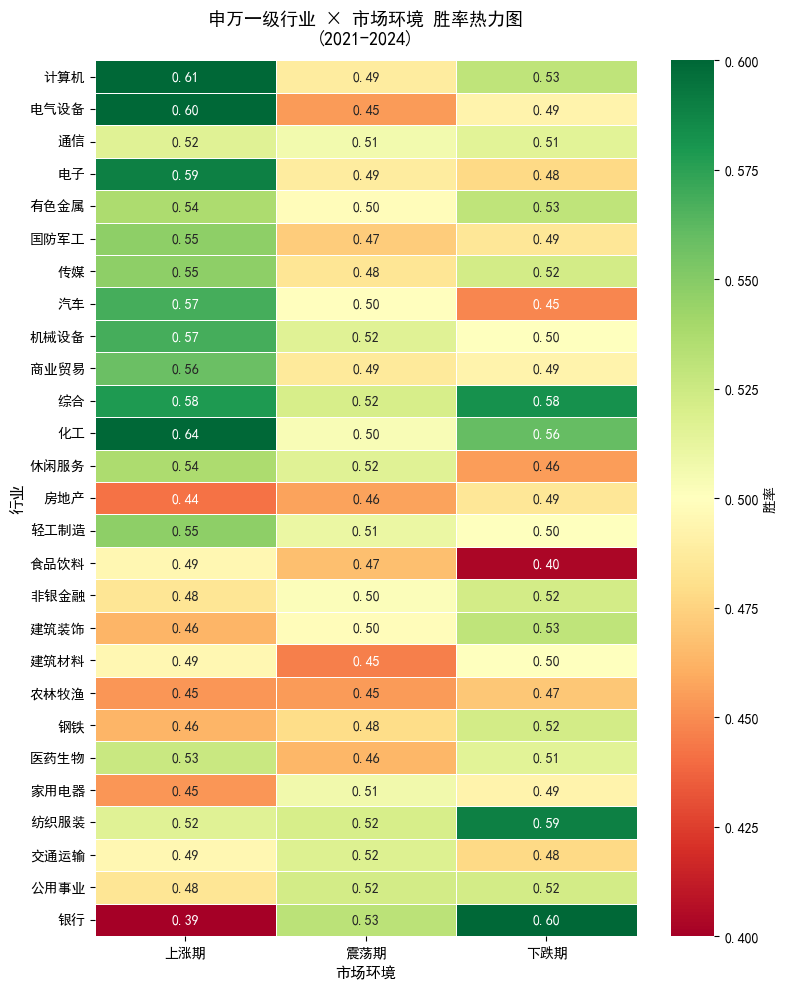

图已保存


In [36]:
pivot_winrate = df_alpha.pivot(
    index='行业名称',
    columns='市场环境',
    values='胜率'
)[['上涨期', '震荡期', '下跌期']]

# 保持和上面一样的行业排序
pivot_winrate = pivot_winrate.reindex(pivot_alpha.index)

fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    pivot_winrate,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    vmin=0.4,
    vmax=0.6,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '胜率'}
)

ax.set_title('申万一级行业 × 市场环境 胜率热力图\n(2021-2024)', fontsize=13, pad=12)
ax.set_xlabel('市场环境', fontsize=11)
ax.set_ylabel('行业', fontsize=11)

plt.tight_layout()
plt.savefig('../data/heatmap_winrate.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

两张热力图放在一起，规律非常清晰。胜率图印证了超额收益图的结论，而且多了几个有意思的发现：

银行：上涨期胜率只有0.39（最低），但下跌期胜率0.60（最高），和超额收益图完全一致，是最典型的防御行业。

化工：上涨期胜率0.64，是所有行业最高，但超额收益只有0.0015，说明化工在上涨期赢的天数多，但单日弹性不如计算机电子。

食品饮料：下跌期胜率0.40，是下跌期最差的行业，和超额收益-0.0023对应，2021-2024白酒持续杀估值的痕迹很明显。

行业分组对比折线图，把行业按周期/成长/防御分组，展示累计收益走势

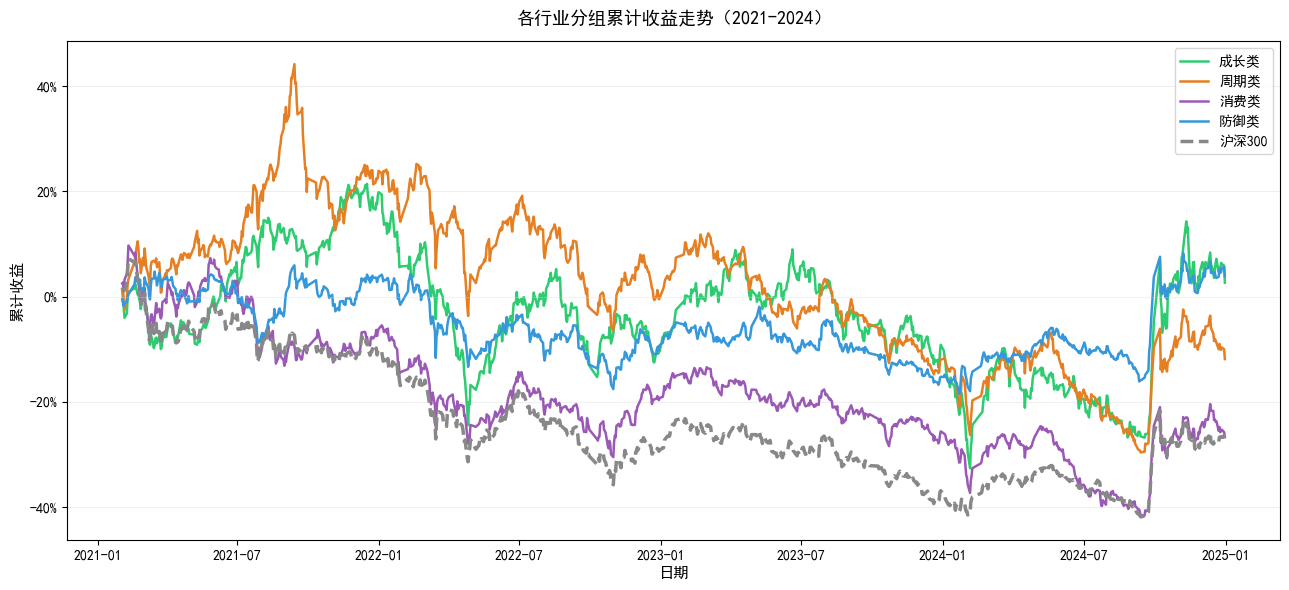

图已保存


In [37]:
# 定义行业分组
group_map = {
    '周期类': ['化工', '钢铁', '有色金属', '建筑材料', '建筑装饰'],
    '成长类': ['计算机', '电子', '电气设备', '通信', '国防军工'],
    '消费类': ['食品饮料', '家用电器', '医药生物', '休闲服务', '纺织服装'],
    '防御类': ['银行', '公用事业', '交通运输', '非银金融'],
}

# 给df_merged打上分组标签
def get_group(name):
    for group, industries in group_map.items():
        if name in industries:
            return group
    return '其他'

df_merged['行业分组'] = df_merged['行业名称'].apply(get_group)

# 计算各分组每日平均涨跌幅
df_group_daily = df_merged.groupby(['日期', '行业分组'])['日涨跌幅'].mean().reset_index()

# 计算累计收益
df_group_daily = df_group_daily.sort_values(['行业分组', '日期'])
df_group_daily['累计收益'] = df_group_daily.groupby('行业分组')['日涨跌幅'].transform(
    lambda x: (1 + x).cumprod() - 1
)

# 同时计算沪深300累计收益作为基准
df_hs300_cum = df_hs300[['日期', '日涨跌幅']].copy()
df_hs300_cum = df_hs300_cum[df_hs300_cum['日期'].isin(df_group_daily['日期'])]
df_hs300_cum['累计收益'] = (1 + df_hs300_cum['日涨跌幅']).cumprod() - 1
df_hs300_cum['行业分组'] = '沪深300'

# 合并
df_plot = pd.concat([
    df_group_daily[df_group_daily['行业分组'] != '其他'][['日期', '行业分组', '累计收益']],
    df_hs300_cum[['日期', '行业分组', '累计收益']]
])

# 画图
fig, ax = plt.subplots(figsize=(13, 6))

colors = {
    '成长类': '#2ecc71',
    '周期类': '#e67e22',
    '消费类': '#9b59b6',
    '防御类': '#3498db',
    '沪深300': '#888888',
}

for group, color in colors.items():
    data = df_plot[df_plot['行业分组'] == group].sort_values('日期')
    lw = 2.5 if group == '沪深300' else 1.8
    ls = '--' if group == '沪深300' else '-'
    ax.plot(data['日期'], data['累计收益'], label=group, color=color, linewidth=lw, linestyle=ls)

ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
ax.set_title('各行业分组累计收益走势（2021-2024）', fontsize=13, pad=12)
ax.set_xlabel('日期', fontsize=11)
ax.set_ylabel('累计收益', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../data/cumreturn_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

图里的关键事件一目了然：

2021上半年周期类暴涨40%，对应碳中和+大宗商品超级周期

2022年全线下跌，沪深300跌到-35%，消费类跌最惨

2024年底所有分组集体拉升，对应9月底政策转向

全程消费类跑输最多，白酒估值杀跌贯穿始终

把数据保存成可复用的格式

In [38]:
df_merged.to_csv('../data/df_merged.csv', index=False, encoding='utf-8-sig')
df_alpha.to_csv('../data/df_alpha.csv', index=False, encoding='utf-8-sig')
print('分析数据已保存')

分析数据已保存
